In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_csv("../data/Dataset_Feature_Engineered.csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Restaurant_Name_Length,Address_Length,Table_Booking,Online_Delivery
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,16,71,1,0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,16,67,1,0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,22,56,1,0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,4,70,0,0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,11,64,1,0


In [3]:
df[[
    "Cuisines",
    "Votes",
    "Aggregate rating"
]].head()

,Cuisines,Votes,Aggregate rating
0,"French, Japanese, Desserts",314,4.8
1,Japanese,591,4.5
2,"Seafood, Asian, Filipino, Indian",270,4.4
3,"Japanese, Sushi",365,4.9
4,"Japanese, Korean",229,4.8


In [4]:
popular_cuisine = (
    df.groupby("Cuisines")["Votes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

popular_cuisine

Cuisines
North Indian, Mughlai             53747
North Indian                      46241
North Indian, Chinese             42012
Cafe                              30657
Chinese                           21925
North Indian, Mughlai, Chinese    20115
Fast Food                         17852
South Indian                      16433
Mughlai, North Indian             15275
Italian                           14799
Name: Votes, dtype: int64

C:\Users\asus\AppData\Local\Temp\ipykernel_26676\932454789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


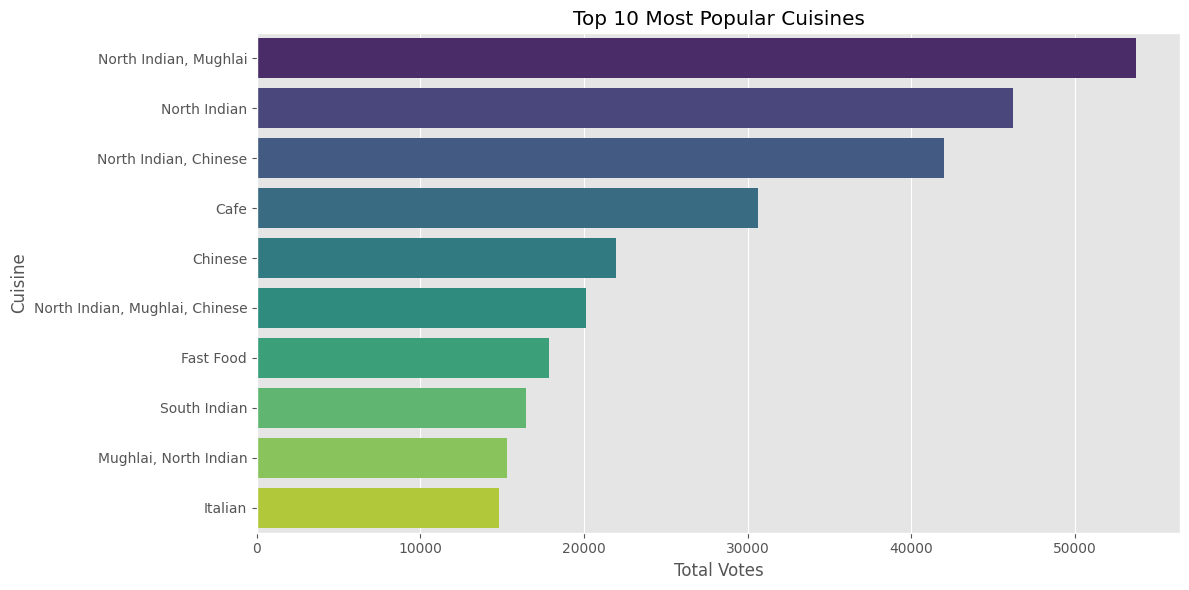

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=popular_cuisine.values,
    y=popular_cuisine.index,
    palette="viridis"
)

plt.title("Top 10 Most Popular Cuisines")

plt.xlabel("Total Votes")

plt.ylabel("Cuisine")

plt.tight_layout()

plt.savefig("../images/top10_popular_cuisines.png", dpi=300)

plt.show()

In [6]:
highest_rating = (
    df.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

highest_rating

Cuisines
American, Coffee and Tea    4.9
American, BBQ, Sandwich     4.9
Burger, Bar Food, Steak     4.9
Sunda, Indonesian           4.9
Mughlai, Lucknowi           4.9
European, German            4.9
European, Contemporary      4.9
European, Asian, Indian     4.9
Italian, Deli               4.9
American, Sandwich, Tea     4.9
Name: Aggregate rating, dtype: float64

C:\Users\asus\AppData\Local\Temp\ipykernel_26676\3825587509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


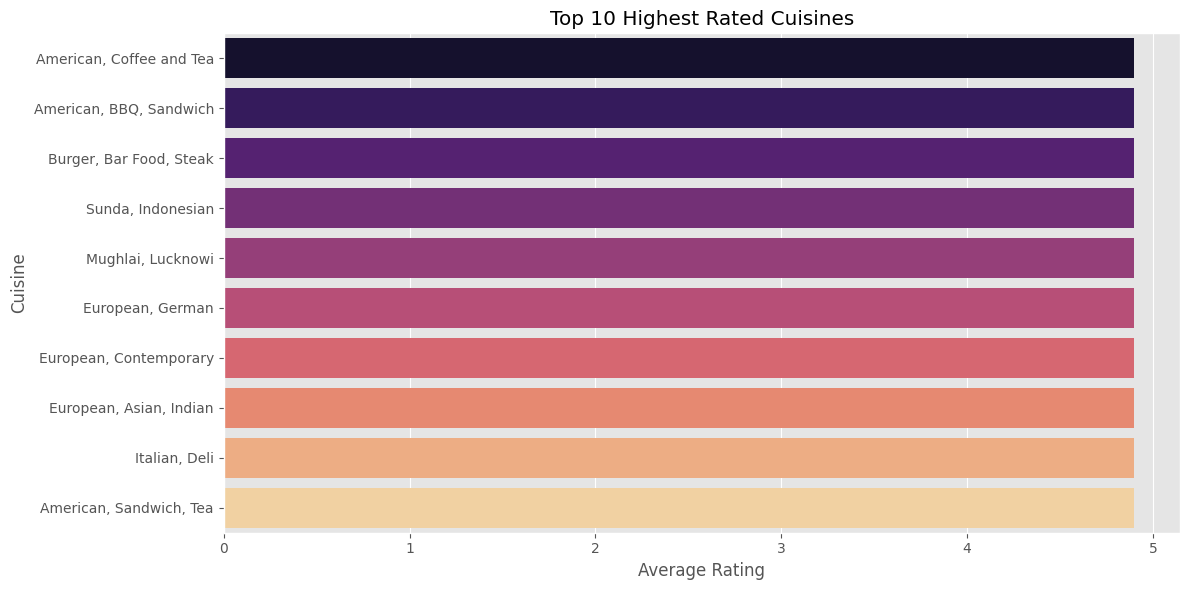

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=highest_rating.values,
    y=highest_rating.index,
    palette="magma"
)

plt.title("Top 10 Highest Rated Cuisines")

plt.xlabel("Average Rating")

plt.ylabel("Cuisine")

plt.tight_layout()

plt.savefig("../images/highest_rated_cuisines.png", dpi=300)

plt.show()

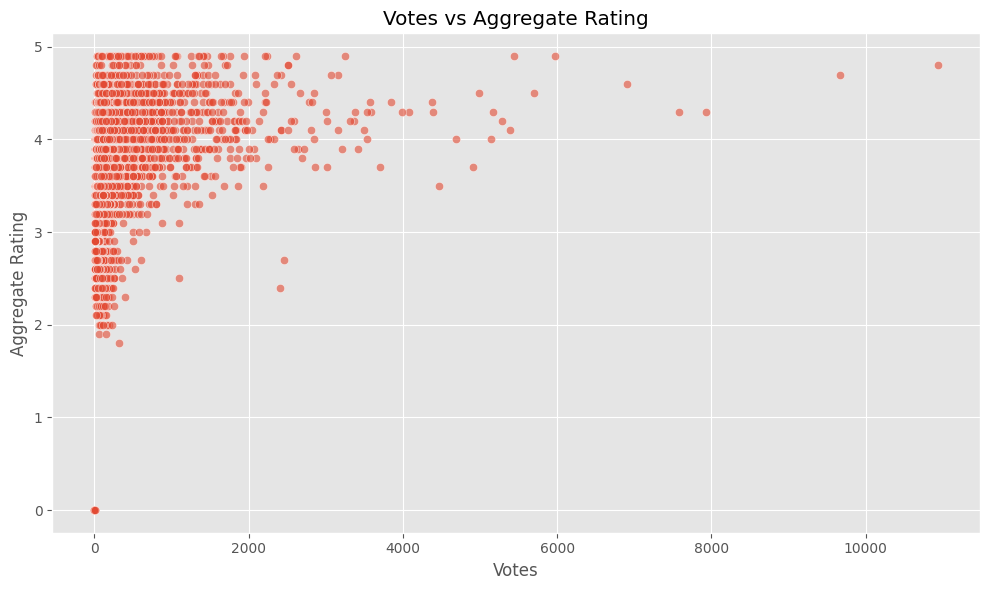

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Votes",
    y="Aggregate rating",
    alpha=0.6
)

plt.title("Votes vs Aggregate Rating")

plt.xlabel("Votes")

plt.ylabel("Aggregate Rating")

plt.tight_layout()

plt.savefig("../images/votes_vs_rating.png", dpi=300)

plt.show()

In [9]:
top_restaurants = df[[
    "Restaurant Name",
    "Cuisines",
    "Aggregate rating",
    "Votes"
]].sort_values(
    by="Aggregate rating",
    ascending=False
).head(10)

top_restaurants

,Restaurant Name,Cuisines,Aggregate rating,Votes
50,Garota de Ipanema,"Brazilian, Bar Food",4.9,49
10,Silantro Fil-Mex,"Filipino, Mexican",4.9,1070
3,Ooma,"Japanese, Sushi",4.9,365
509,Mr. Dunderbak's Biergarten and Marketplatz,"European, German",4.9,1413
507,Mazzaro's Italian Market,"Italian, Deli",4.9,1424
39,Coco Bambu,International,4.9,30
124,Rae's Coastal Cafe,"American, Caribbean, Seafood",4.9,548
48,Braseiro da G��vea,"Brazilian, Bar Food",4.9,40
9538,Starbucks,Cafe,4.9,1042
9299,Milse,Desserts,4.9,754
